## Mall Customers Clustering with KMeans, DBSCAN, & Agglomerative - Unsupervised Learning

> Tugas ini bertujuan untuk membangun model clustering pelanggan mall dengan KMeans, DBSCAN, dan Agglomerative. Dataset berasal dari sini : https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/Mall_Customers.csv

> Referensi : https://colab.research.google.com/drive/1H1CGYKyAQ1mjy6vDAzhgeVctEOOeLPqC?usp=sharing


Nama: Nicholas Kisu Candra

Program: AI Development

### 1. Import module yang diperlukan

In [ ]:
# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering P
from sklearn.metrics import silhouette_score

### TODO #1 :

> Isi insight : Sebenarnya, bagaimana ciri-ciri dari sebuah dataset yang bisa dipakai untuk clustering?

Ciri-ciri dataset yang bisa dipakai untuk clustering:
1. Tidak ada label (tidak ada target seperti `y` sehingga tidak tahu jawaban benar)
2. Ada pola / struktur dalam data (data tidak random)
3. Fitur merepresentasikan kemiripan (data mirip = dekat, data berbeda = jauh)
4. Perbeaan antar kelompok cukup jelas (cluster bisa dipisahkan walaupun tidak sempurna)
5. Tidak terlalu banyak noise


Dataset yang cocok untuk clustering umumnya tidak memiliki label atau target, sehingga digunakan untuk menemukan pola atau kelompok secara otomatis dari data. Selain itu, data harus memiliki struktur atau pola tertentu, di mana terdapat kemiripan antar data dalam satu kelompok dan perbedaan yang cukup jelas antar kelompok yang berbeda. Fitur yang digunakan juga harus relevan dalam merepresentasikan karakteristik data, sehingga jarak atau kedekatan antar data dapat mencerminkan kemiripan sebenarnya. Pada dataset seperti Mall Customers, fitur seperti pendapatan dan skor pengeluaran dapat digunakan untuk mengelompokkan pelanggan berdasarkan perilaku mereka.

### 2. Data collection

In [6]:
# 2. Load Dataset dari GitHub Gist
# url = "https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/Mall_Customers.csv"
url = "Mall_Customers.csv" # alternatif jika sudah download
df = pd.read_csv(url)
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


### 3.  Data preprocessing

In [5]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### TODO #2 :

> Isi insight : Kenapa menggunakan fitur ini? Bagaimana yang lainnya? (CustomerID, Gender)

Fitur yang digunakan dalam clustering dipilih karena mampu merepresentasikan karakteristik perilaku pelanggan. Age, Annual Income, dan Spending Score memiliki hubungan yang relevan dalam menggambarkan pola konsumsi seseorang. Annual Income menunjukkan kemampuan finansial, sedangkan Spending Score mencerminkan kecenderungan seseorang dalam mengeluarkan uang. Age juga dapat mempengaruhi pola tersebut karena perbedaan gaya hidup antar kelompok umur.

Dalam konteks clustering, fitur-fitur ini digunakan karena dapat membentuk kemiripan antar data berdasarkan jarak (distance), sehingga pelanggan dengan karakteristik serupa dapat dikelompokkan dalam satu cluster.

Sementara itu, CustomerID tidak digunakan karena hanya merupakan identifier unik dan tidak memiliki makna dalam menentukan kemiripan antar data. Gender sebenarnya bisa digunakan, namun karena bersifat kategorikal, perlu dilakukan encoding terlebih dahulu dan belum tentu memberikan kontribusi signifikan terhadap pembentukan cluster dibandingkan fitur numerik lainnya.

### 4. KMeans Clustering (k=5)

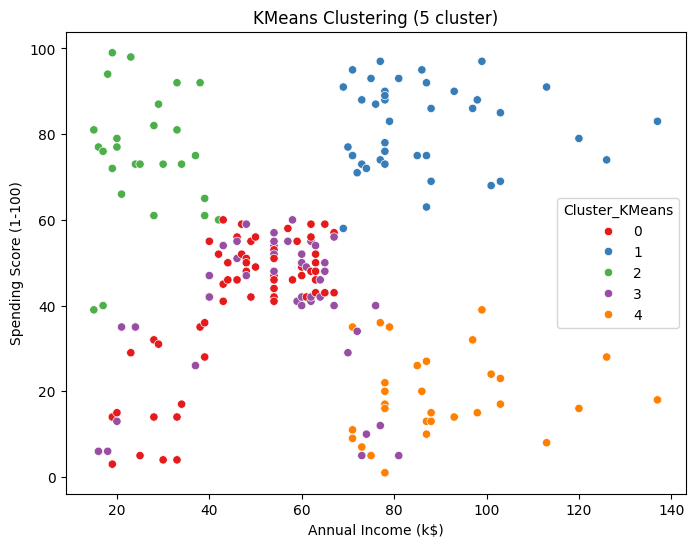



Silhouette Score KMeans: 0.40846873777345605


In [7]:
# KMeans Clustering (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster_KMeans'] = y_kmeans

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_KMeans', palette='Set1')
plt.title("KMeans Clustering (5 cluster)")
plt.show()

print("\n\nSilhouette Score KMeans:", silhouette_score(X_scaled, y_kmeans))


### TODO #3 :

> Isi insight : Bagaimana cara kerja dari K-Means Clustering? Dan apa analisismu terhadap hasil diatas?

K-Means Clustering bekerja dengan cara membagi data ke dalam sejumlah cluster berdasarkan kedekatan jarak terhadap pusat cluster (centroid). Proses dimulai dengan menentukan jumlah cluster (k), kemudian model secara iteratif mengelompokkan data ke centroid terdekat dan memperbarui posisi centroid hingga stabil.

Berdasarkan hasil visualisasi, terlihat bahwa data pelanggan dapat dibagi menjadi beberapa kelompok yang memiliki karakteristik berbeda:

🔴 Cluster 0 (merah)
income rendah
spending rendah

> 👉 “low income – low spender”

🔵 Cluster 1 (biru)
income tinggi
spending tinggi

> 👉 “high income – high spender”

🟢 Cluster 2 (hijau)
income rendah
spending tinggi

> 👉 “low income – impulsive spender”

🟣 Cluster 3 (ungu)
income sedang
spending sedang

> 👉 “average customers”

🟠 Cluster 4 (orange)
income tinggi
spending rendah

> 👉 “rich but saver”

Nilai silhouette score juga menunjukkan bahwa hasil clustering cukup baik, yang berarti jarak antar cluster cukup jelas dan tidak terlalu banyak overlap.

### TODO #4 :

> Isi insight : Apa itu Silhouette Score?

Silhouette Score digunakan untuk mengukur kualitas hasil clustering dengan melihat seberapa dekat suatu data dengan cluster-nya sendiri dibandingkan dengan cluster lain. Nilai yang tinggi menunjukkan bahwa data berada pada cluster yang tepat dan memiliki pemisahan yang jelas dengan cluster lainnya. Sebaliknya, nilai yang rendah atau mendekati nol menunjukkan adanya overlap antar cluster.

Silhouette Score dapat digunakan untuk membantu menentukan jumlah cluster (k) yang optimal pada K-Means.

### 5. DBSCAN Clustering

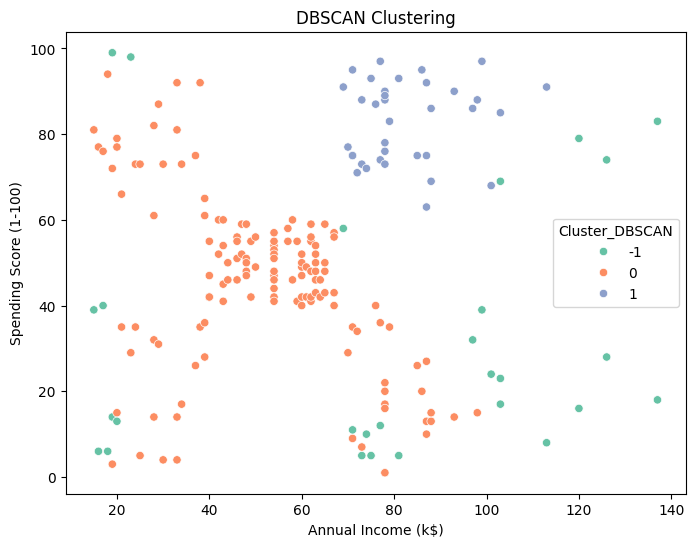



Silhouette Score DBSCAN: 0.18803828359177516


In [8]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=0.6, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = y_dbscan

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_DBSCAN', palette='Set2')
plt.title("DBSCAN Clustering")
plt.show()

print("\n\nSilhouette Score DBSCAN:", silhouette_score(X_scaled, y_dbscan))


### TODO #5 :

> Isi insight : Bagaimana cara kerja dari DBSCAN Clustering? Dan apa analisismu terhadap hasil diatas?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) bekerja dengan cara mengelompokkan data berdasarkan kepadatan (density). Data yang memiliki jumlah tetangga yang cukup dalam radius tertentu (eps) akan membentuk cluster, sedangkan data yang tidak memenuhi syarat tersebut akan dianggap sebagai noise.

Berdasarkan hasil visualisasi, terlihat bahwa DBSCAN hanya membentuk sedikit cluster dan banyak data yang diklasifikasikan sebagai noise (label -1). Hal ini menunjukkan bahwa pola kepadatan pada dataset tidak terlalu jelas. Selain itu, nilai silhouette score yang rendah (sekitar 0.18) menunjukkan bahwa kualitas clustering kurang baik dan terdapat banyak overlap antar cluster.

Hal ini kemungkinan disebabkan oleh pemilihan parameter `eps` dan `min_samples` yang kurang optimal, serta karakteristik dataset yang lebih cocok untuk metode berbasis jarak seperti KMeans dibandingkan metode berbasis kepadatan seperti DBSCAN.

### 6. Agglomerative Clustering

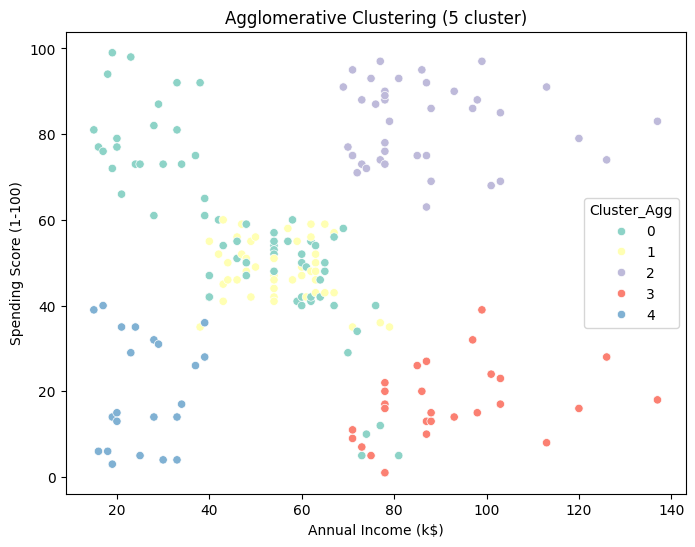



Silhouette Score Agglomerative: 0.39002826186267214


In [9]:
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=5)
y_agg = agg.fit_predict(X_scaled)
df['Cluster_Agg'] = y_agg

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_Agg', palette='Set3')
plt.title("Agglomerative Clustering (5 cluster)")
plt.show()

print("\n\nSilhouette Score Agglomerative:", silhouette_score(X_scaled, y_agg))


### TODO #6 :

> Isi insight : Bagaimana cara kerja dari Agglomerative Clustering? Dan apa analisismu terhadap hasil diatas?

Agglomerative Clustering merupakan metode hierarchical clustering yang bekerja dengan cara menggabungkan data secara bertahap berdasarkan kemiripan. Pada awalnya, setiap data dianggap sebagai satu cluster, kemudian dua cluster yang paling dekat akan digabungkan. Proses ini terus dilakukan hingga jumlah cluster yang diinginkan tercapai.

Berdasarkan hasil visualisasi, terlihat bahwa data dapat dibagi menjadi beberapa kelompok yang cukup jelas, terutama berdasarkan kombinasi pendapatan dan skor pengeluaran. Hasil clustering juga menunjukkan pola yang mirip dengan KMeans, meskipun tidak seoptimal dalam pemisahan cluster.

Nilai silhouette score sebesar sekitar 0.39 menunjukkan bahwa kualitas clustering cukup baik, meskipun masih terdapat overlap antar cluster. Jika dibandingkan dengan metode lain, Agglomerative Clustering memberikan hasil yang lebih baik dibandingkan DBSCAN, namun masih sedikit di bawah KMeans dalam hal kualitas pemisahan data.

### 7. Perbandingan

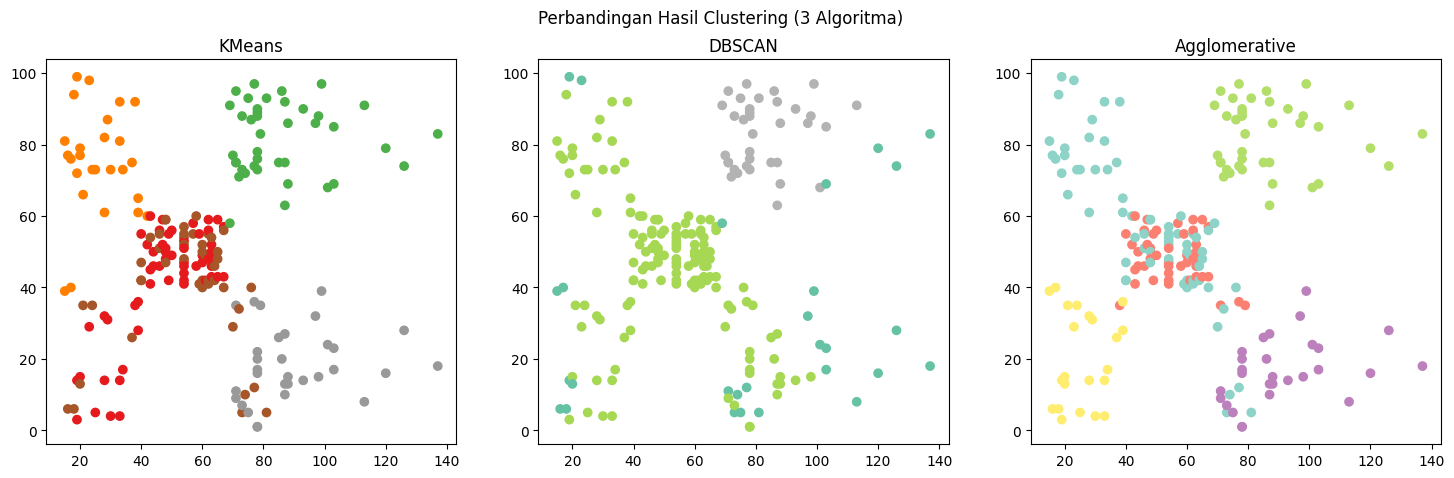

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_KMeans'], cmap='Set1')
axs[0].set_title('KMeans')

axs[1].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_DBSCAN'], cmap='Set2')
axs[1].set_title('DBSCAN')

axs[2].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_Agg'], cmap='Set3')
axs[2].set_title('Agglomerative')

plt.suptitle("Perbandingan Hasil Clustering (3 Algoritma)")
plt.show()


## TODO #7 **Analisis Visual: Perbandingan Hasil Clustering (3 Algoritma)**

(Isi TODO dibawah)

### **1. KMeans**

Pada hasil KMeans, terlihat bahwa data terbagi menjadi beberapa cluster yang cukup jelas dan terpisah dengan baik. Setiap cluster memiliki batas yang relatif rapi karena KMeans bekerja berdasarkan jarak ke centroid. Pola pelanggan seperti kelompok dengan pendapatan tinggi dan pengeluaran tinggi maupun rendah dapat terlihat dengan jelas. Hal ini menunjukkan bahwa KMeans mampu menangkap struktur data dengan baik pada dataset ini.

---

### **2. DBSCAN**

Pada hasil DBSCAN, terlihat bahwa jumlah cluster yang terbentuk lebih sedikit dan terdapat banyak data yang diklasifikasikan sebagai noise (label -1). Hal ini menunjukkan bahwa algoritma kesulitan menemukan area dengan kepadatan yang cukup jelas. Beberapa data yang sebenarnya membentuk kelompok justru tidak tergabung dalam cluster. Hal ini kemungkinan disebabkan oleh parameter eps yang kurang optimal atau karakteristik data yang tidak berbasis kepadatan yang kuat.

---

### **3. Agglomerative Clustering**

Hasil Agglomerative Clustering menunjukkan pembagian cluster yang cukup mirip dengan KMeans, meskipun batas antar cluster tidak sejelas KMeans. Algoritma ini mampu mengelompokkan data berdasarkan kemiripan secara bertahap, sehingga pola utama dalam data tetap terlihat. Namun, masih terdapat beberapa overlap antar cluster yang menunjukkan bahwa pemisahan tidak sepenuhnya optimal

---

## Kesimpulan Naratif

Berdasarkan perbandingan ketiga algoritma, KMeans memberikan hasil clustering yang paling jelas dan terpisah dengan baik pada dataset ini. Agglomerative Clustering juga mampu menghasilkan cluster yang cukup baik, meskipun tidak seoptimal KMeans dalam hal pemisahan. Sementara itu, DBSCAN kurang cocok untuk dataset ini karena tidak mampu menangkap pola cluster dengan baik dan menghasilkan banyak noise. Hal ini menunjukkan bahwa pemilihan algoritma clustering sangat bergantung pada karakteristik data, di mana metode berbasis jarak seperti KMeans lebih sesuai untuk dataset dengan pola seperti Mall Customers.

